# DS 612 — Group Project: Used Car Price Prediction

**Authors:** Ana Sachuk · Terry · Nadine · Aarnav

**Dataset:** Craigslist Used Vehicle Listings (`vehicles.csv`) — 426,880 records

**Research Question:** Can we accurately predict the listing price of a used car from its attributes?

---

| Section | Author | Content |
|---|---|---|
| 1 | Ana | Data Cleaning + Baseline Models (Linear, Decision Tree, Ridge) |
| 2 | Terry | Polynomial Regression, Tuned Random Forest + Visualizations |
| 3 | Nadine | Random Forest + MLR + Model Comparison |

In [61]:
# Imports For the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
notebook_start = time.time()

In [62]:
# Load dataset once — all sections share this raw dataframe
vehiclesdf_unclean = pd.read_csv("vehicles.csv")
print(f"Raw dataset: {vehiclesdf_unclean.shape[0]:,} rows × {vehiclesdf_unclean.shape[1]} columns")


Raw dataset: 426,880 rows × 26 columns


In [63]:
# Clean once — drop low-coverage columns & NaN rows, shared by all sections
vehiclesdfc = vehiclesdf_unclean[["id","region","region_url","price","year",
                                  "manufacturer","model","condition",
                                  "cylinders","state","posting_date"]]
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()
print(f"Cleaned dataset: {vehiclesdfc.shape[0]:,} rows × {vehiclesdfc.shape[1]} columns")
vehiclesdfc.head()


Cleaned dataset: 404,020 rows × 9 columns


,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


---
# Section 1 — Ana's Work
*(from `Datacleaning.ipynb` and `ana_model.ipynb`)*

In [64]:
# Ana — take a fresh copy of the shared cleaned dataset
vehiclesdfc = vehiclesdfc.copy()


In [65]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


In [66]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(404020, 9)
 
<class 'pandas.core.frame.DataFrame'>
Index: 404020 entries, 27 to 426879
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            404020 non-null  int64  
 1   region        404020 non-null  object 
 2   region_url    404020 non-null  object 
 3   price         404020 non-null  int64  
 4   year          404020 non-null  float64
 5   manufacturer  404020 non-null  object 
 6   model         404020 non-null  object 
 7   state         404020 non-null  object 
 8   posting_date  404020 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 30.8+ MB
None
                 id         price           year
count  4.040200e+05  4.040200e+05  404020.000000
mean   7.311503e+09  6.218580e+04    2011.657180
std    4.374469e+06  1.124254e+07       8.570535
min    7.301583e+09  0.000000e+00    1900.000000
25%    7.308152e+09  5.995000e+03    2009.000000
50%    7.312635e+09  1.399500e+04 

In [67]:
# Due to condition and cylinders being at 40% with NaN values then we should drop it
# (already dropped at top — errors='ignore' makes this a safe no-op)
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"], errors="ignore")
vehiclesdfc = vehiclesdfc.dropna()


In [68]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


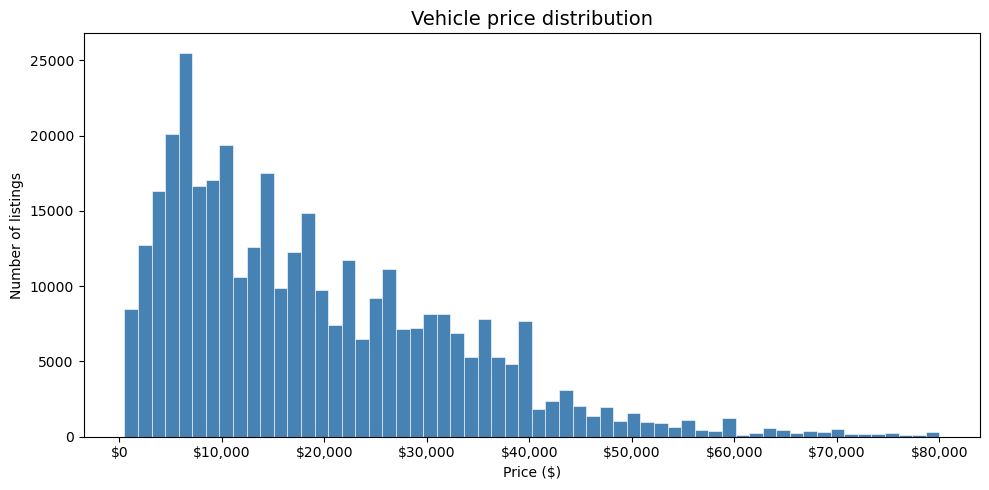

In [69]:
# Filter out extreme outliers first
df_plot = vehiclesdfc[vehiclesdfc['price'].between(500, 80000)]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_plot['price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)

ax.set_title('Vehicle price distribution', fontsize=14)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.show()

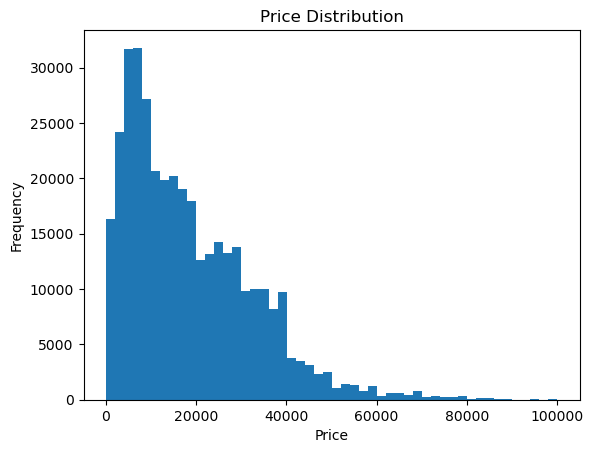

In [70]:
# clean out bad price values FIRST
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] > 100]
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] < 100000]

# THEN plot
import matplotlib.pyplot as plt

plt.hist(vehiclesdfc['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [71]:
# selecting features for modeling
df_model = vehiclesdfc[['price', 'year']]
df_model = df_model.dropna()

In [72]:
# X = features, y = target
X = df_model[['year']]
y = df_model['price']

In [73]:
from sklearn.model_selection import train_test_split

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

mse1 = mean_squared_error(y_test, y_pred1)
print("Linear Regression MSE:", mse1)

Linear Regression MSE: 173506510.83536044


In [75]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor(max_depth=5)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
print("Decision Tree MSE:", mse2)

Decision Tree MSE: 121691352.05825746


In [76]:
# Model 3: Ridge Regression
from sklearn.linear_model import Ridge

model3 = Ridge(alpha=1.0)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

mse3 = mean_squared_error(y_test, y_pred3)
print("Ridge MSE:", mse3)

Ridge MSE: 173506510.86493984


---
### Section 1 Comparison — Ana's Models


Section 1 — Ana's Models  (feature: year only)
                  Model    R² MAE ($) RMSE ($)
      Linear Regression 0.149  10,127   13,172
Decision Tree (depth=5) 0.403   7,923   11,031
       Ridge Regression 0.149  10,127   13,172


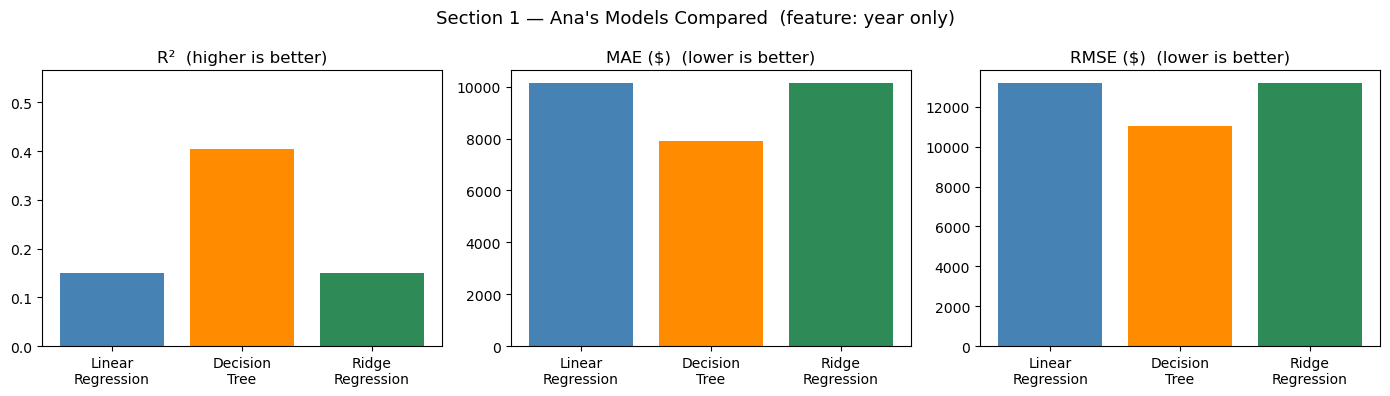

In [77]:
# Full metrics for Ana's 3 models (feature: year only)
ana_lr_r2,    ana_lr_mae,    ana_lr_rmse    = (r2_score(y_test, y_pred1),
                                                mean_absolute_error(y_test, y_pred1),
                                                np.sqrt(mean_squared_error(y_test, y_pred1)))
ana_dt_r2,    ana_dt_mae,    ana_dt_rmse    = (r2_score(y_test, y_pred2),
                                                mean_absolute_error(y_test, y_pred2),
                                                np.sqrt(mean_squared_error(y_test, y_pred2)))
ana_ridge_r2, ana_ridge_mae, ana_ridge_rmse = (r2_score(y_test, y_pred3),
                                                mean_absolute_error(y_test, y_pred3),
                                                np.sqrt(mean_squared_error(y_test, y_pred3)))

ana_comp = pd.DataFrame({
    "Model":    ["Linear Regression", "Decision Tree (depth=5)", "Ridge Regression"],
    "R²":       [f"{ana_lr_r2:.3f}",    f"{ana_dt_r2:.3f}",    f"{ana_ridge_r2:.3f}"],
    "MAE ($)":  [f"{ana_lr_mae:,.0f}",  f"{ana_dt_mae:,.0f}",  f"{ana_ridge_mae:,.0f}"],
    "RMSE ($)": [f"{ana_lr_rmse:,.0f}", f"{ana_dt_rmse:,.0f}", f"{ana_ridge_rmse:,.0f}"],
})
print("Section 1 — Ana's Models  (feature: year only)")
print(ana_comp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_labels = ["Linear\nRegression", "Decision\nTree", "Ridge\nRegression"]
_colors = ["steelblue", "darkorange", "seagreen"]

axes[0].bar(_labels, [ana_lr_r2, ana_dt_r2, ana_ridge_r2], color=_colors)
axes[0].set_title("R²  (higher is better)")
axes[0].set_ylim(0, max(ana_lr_r2, ana_dt_r2, ana_ridge_r2) * 1.4 + 0.001)

axes[1].bar(_labels, [ana_lr_mae, ana_dt_mae, ana_ridge_mae], color=_colors)
axes[1].set_title("MAE ($)  (lower is better)")

axes[2].bar(_labels, [ana_lr_rmse, ana_dt_rmse, ana_ridge_rmse], color=_colors)
axes[2].set_title("RMSE ($)  (lower is better)")

plt.suptitle("Section 1 — Ana's Models Compared  (feature: year only)", fontsize=13)
plt.tight_layout()
plt.show()


In [78]:
elapsed = time.time() - notebook_start
print(f"Time since start: {elapsed:.1f}s  ({elapsed/60:.1f} min)")

Time since start: 72.3s  (1.2 min)


---
# Section 2 — Terry's Work
*(from `Terry_model_testing.ipynb`)*

#This is the clean data set 

In [79]:
# Terry — take a fresh copy of the shared cleaned dataset
vehiclesdfc = vehiclesdfc.copy()
vehiclesdfc.head()


,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


In [80]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


In [81]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(369724, 9)
 
<class 'pandas.core.frame.DataFrame'>
Index: 369724 entries, 27 to 426879
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            369724 non-null  int64  
 1   region        369724 non-null  object 
 2   region_url    369724 non-null  object 
 3   price         369724 non-null  int64  
 4   year          369724 non-null  float64
 5   manufacturer  369724 non-null  object 
 6   model         369724 non-null  object 
 7   state         369724 non-null  object 
 8   posting_date  369724 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 28.2+ MB
None
                 id          price           year
count  3.697240e+05  369724.000000  369724.000000
mean   7.311500e+09   18875.354697    2011.461414
std    4.380117e+06   14256.569977       8.673256
min    7.301583e+09     101.000000    1900.000000
25%    7.308142e+09    7500.000000    2008.000000
50%    7.312655e+09   15590.

In [82]:
# Due to condition and cylinders being at 40% with NaN values then we should drop it
# (already dropped at top — errors='ignore' makes this a safe no-op)
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"], errors="ignore")
vehiclesdfc = vehiclesdfc.dropna()


In [83]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


# Next are models: Multiple Linear Regression, Polynomial Regression, and Random Forest regression

In [84]:
# 1. Drop columns that won't help predict price or are too messy (like URLs and IDs)
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehiclesdfc.drop(columns=columns_to_drop)

# 2. Convert remaining text (like 'manufacturer') into 1s and 0s
ml_df = pd.get_dummies(ml_df, drop_first=True)

# 3. Separate Features (X) and Target (y)
X = ml_df.drop('price', axis=1)
y = ml_df['price']

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared! Training on {len(X_train)} samples.")

Data prepared! Training on 295779 samples.


In [85]:
# 1. Filter out the "trash" prices and years
# This removes the $0 and $1 entries that are breaking your math
vehicles_filtered = vehiclesdfc[(vehiclesdfc['price'] > 500) & (vehiclesdfc['price'] < 150000)]
vehicles_filtered = vehicles_filtered[(vehicles_filtered['year'] > 1990) & (vehicles_filtered['year'] < 2025)]

# 2. Re-run the preparation
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehicles_filtered.drop(columns=columns_to_drop)
ml_df = pd.get_dummies(ml_df, drop_first=True)

X = ml_df.drop('price', axis=1)
y = ml_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now run your models - you should see positive R-squared values!

In [86]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the Transformer (degree=2 creates Year^2)
poly = PolynomialFeatures(degree=2)

# 2. Transform your original X data into Polynomial data
# This creates the 'X_train_poly' and 'X_test_poly' variables the model is looking for
X_train_poly = poly.fit_transform(X_train[['year']])
X_test_poly = poly.transform(X_test[['year']])

# 3. NOW your existing code will work:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [87]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
print(f"Polynomial Regression (Year Only) R-squared: {r2_score(y_test, y_pred_poly):.4f}")

Polynomial Regression (Year Only) R-squared: 0.4330


# I should've scored higher with this model, but due to a lack of information, it scored low 

# Random Forest Regressor is the best model to use out of the three

In [88]:
# --- Tuned Random Forest Regressor ---
# n_estimators: Number of trees (more is usually better but slower)
# max_depth: Limits how complex each tree gets to prevent overfitting
# n_jobs=-1: Uses all your computer's processors to speed it up

rf_tuned = RandomForestRegressor(
    n_estimators=300, 
    max_depth=15, 
    min_samples_split=5, 
    random_state=42, 
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

print(f"Original Random Forest R-squared: 0.5724")
print(f"Tuned Random Forest R-squared: {r2_score(y_test, y_pred_tuned):.4f}")

Original Random Forest R-squared: 0.5724
Tuned Random Forest R-squared: 0.5414


In [89]:
# Capture poly + rf_tuned metrics before y_test is overwritten by the cell below
terry_poly_r2    = r2_score(y_test, y_pred_poly)
terry_poly_mae   = mean_absolute_error(y_test, y_pred_poly)
terry_poly_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_poly))

terry_rftuned_r2   = r2_score(y_test, y_pred_tuned)
terry_rftuned_mae  = mean_absolute_error(y_test, y_pred_tuned)
terry_rftuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"Poly      R²: {terry_poly_r2:.3f}  MAE: ${terry_poly_mae:,.0f}  RMSE: ${terry_poly_rmse:,.0f}")
print(f"RF Tuned  R²: {terry_rftuned_r2:.3f}  MAE: ${terry_rftuned_mae:,.0f}  RMSE: ${terry_rftuned_rmse:,.0f}")


Poly      R²: 0.433  MAE: $7,676  RMSE: $10,624
RF Tuned  R²: 0.541  MAE: $6,639  RMSE: $9,555


# set max_depth to 15, which focuses on the general picture and getting rid of outliers that don't represent the whole market 

In [90]:
df=vehiclesdfc.copy()

In [ ]:
# 1. Start fresh from your original data
df = vehiclesdfc.copy()
df.columns = [col.lower().strip() for col in df.columns]

# 2. Filter outliers (The "Clean-Up")
# We remove ultra-cheap cars (usually scams/parts) and ultra-expensive ones
df = df[(df['price'] > 1000) & (df['price'] < 80000)]

# 3. Feature Engineering
df['age'] = 2026 - df['year']

# 4. Use Manufacturer and State (One-Hot Encoding)
# We select the columns that actually impact price
features = ['age', 'manufacturer', 'state']
X = df[features].dropna()
y = df.loc[X.index, 'price'] # Match y to the rows we kept in X

# Convert text (Ford, Tesla, NY, CA) into numbers the model can read
X_encoded = pd.get_dummies(X, columns=['manufacturer', 'state'], drop_first=True)

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_boosted = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_boosted.fit(X_train, y_train)

# 6. Check the new score
predictions = rf_boosted.predict(X_test)
print(f"New R-squared : {r2_score(y_test, predictions):.4f}")

In [ ]:
# Terry's RF Boosted — capture metrics (age + manufacturer + state feature set)
terry_rfboosted_r2   = r2_score(y_test, predictions)
terry_rfboosted_mae  = mean_absolute_error(y_test, predictions)
terry_rfboosted_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"RF Boosted  R²: {terry_rfboosted_r2:.3f}  MAE: ${terry_rfboosted_mae:,.0f}  RMSE: ${terry_rfboosted_rmse:,.0f}")


In [ ]:
# 1. SETUP: Prepare the data
df_viz = vehiclesdfc.copy()
df_viz.columns = [col.lower().strip() for col in df_viz.columns]
df_viz = df_viz[(df_viz['price'] > 1000) & (df_viz['price'] < 80000)].dropna(subset=['price', 'year'])
df_viz['age'] = 2026 - df_viz['year']

In [ ]:
# --- PLOT 1: Price Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df_viz['price'], kde=True, color='royalblue')
plt.title('1. Distribution of Car Prices', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

In [ ]:
#PLOT 2: Depreciation Curve 
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_viz, x='year', y='price', color='forestgreen')
plt.title('2. Average Price Trend by Year (Depreciation)', fontsize=15)
plt.xlabel('Model Year')
plt.show()

In [ ]:
# --- PLOT 3: Top 10 Brands ---
plt.figure(figsize=(12, 6))
top_brands = df_viz['manufacturer'].value_counts().nlargest(10).index
sns.boxplot(data=df_viz[df_viz['manufacturer'].isin(top_brands)], x='manufacturer', y='price', hue='manufacturer', palette='Set2', legend=False)
plt.title('3. Price Ranges for Top 10 Brands', fontsize=15)
plt.xticks(rotation=45)
plt.show()

---
### Section 2 Comparison — Terry's Models


In [ ]:
terry_comp = pd.DataFrame({
    "Model":    ["Polynomial Regression (year²)", "RF Tuned (year+mfr)", "RF Boosted (age+mfr+state)"],
    "R²":       [f"{terry_poly_r2:.3f}",       f"{terry_rftuned_r2:.3f}",   f"{terry_rfboosted_r2:.3f}"],
    "MAE ($)":  [f"{terry_poly_mae:,.0f}",     f"{terry_rftuned_mae:,.0f}", f"{terry_rfboosted_mae:,.0f}"],
    "RMSE ($)": [f"{terry_poly_rmse:,.0f}",    f"{terry_rftuned_rmse:,.0f}",f"{terry_rfboosted_rmse:,.0f}"],
})
print("Section 2 — Terry's Models")
print(terry_comp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_labels = ["Poly\nRegression", "RF\nTuned", "RF\nBoosted"]
_colors = ["steelblue", "darkorange", "seagreen"]

axes[0].bar(_labels, [terry_poly_r2, terry_rftuned_r2, terry_rfboosted_r2], color=_colors)
axes[0].set_title("R²  (higher is better)")
axes[0].set_ylim(0, max(terry_poly_r2, terry_rftuned_r2, terry_rfboosted_r2) * 1.3)

axes[1].bar(_labels, [terry_poly_mae, terry_rftuned_mae, terry_rfboosted_mae], color=_colors)
axes[1].set_title("MAE ($)  (lower is better)")

axes[2].bar(_labels, [terry_poly_rmse, terry_rftuned_rmse, terry_rfboosted_rmse], color=_colors)
axes[2].set_title("RMSE ($)  (lower is better)")

plt.suptitle("Section 2 — Terry's Models Compared", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
elapsed = time.time() - notebook_start
print(f"Time since start: {elapsed:.1f}s  ({elapsed/60:.1f} min)")

---
# Section 3 — Nadine's Work
*(from `nadine_model.ipynb`)*

## Data Cleaning

In [ ]:
# Nadine — take a fresh copy of the shared cleaned dataset
vehiclesdfc = vehiclesdfc.copy()


In [ ]:
vehiclesdfc.head()

In [ ]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

In [ ]:
# Due to condition and cylinders being at 40% with NaN values then we should drop it
# (already dropped at top — errors='ignore' makes this a safe no-op)
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"], errors="ignore")
vehiclesdfc = vehiclesdfc.dropna()


In [ ]:
vehiclesdfc.head()

## Preprocessing

In [ ]:
df = vehiclesdfc.copy()
df = df[(df["price"] >= 500) & (df["price"] <= 150_000)]
df["year"] = df["year"].astype(int)

print(f"After outlier removal: {df.shape}")
df["price"].describe()

## Random Forest

**Feature engineering** 

In [ ]:
df_rf = df.copy()

# Limit OHE to top 200 models — freeform Craigslist entries create 22,000+ unique
# model names, which makes training extremely slow. Keeping the top 200 covers the
# vast majority of listings while keeping the feature matrix manageable.
top_models = df_rf["model"].value_counts().nlargest(200).index
df_rf["model_grouped"] = df_rf["model"].where(df_rf["model"].isin(top_models), other="other")
model_ohe = pd.get_dummies(df_rf["model_grouped"], prefix="model", drop_first=True)

# Label encode the remaining low-cardinality categoricals
for col in ["manufacturer", "region", "state"]:
    le = LabelEncoder()
    df_rf[col + "_encoded"] = le.fit_transform(df_rf[col].astype(str))

# Combine all features
base_features = ["year", "manufacturer_encoded", "region_encoded", "state_encoded"]
X_rf = pd.concat([df_rf[base_features], model_ohe], axis=1)
y_rf = df_rf["price"]

print(f"X shape: {X_rf.shape}  (base features + {model_ohe.shape[1]} model dummies)")
print(f"y shape: {y_rf.shape}")

**Train/Test Split**

In [ ]:
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=0)

**Train model**

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1,random_state=0)
rf_model.fit(X_rf_train, y_rf_train)

**Evaluate**

In [ ]:
y_rf_pred = rf_model.predict(X_rf_test)

mae  = mean_absolute_error(y_rf_test, y_rf_pred)
rmse = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
r2   = r2_score(y_rf_test, y_rf_pred)

print(f"MAE :  ${mae:,.0f}")
print(f"RMSE:  ${rmse:,.0f}")
print(f"R\u00b2  :  {r2:.3f}")

In [ ]:
# aliases so the comparison table below can reference rf_mae, rf_rmse, rf_r2
rf_mae, rf_rmse, rf_r2 = mae, rmse, r2

**Visualization**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Top 15 most important features (OHE creates too many to show all)
importances = pd.Series(rf_model.feature_importances_, index=X_rf.columns)
importances.nlargest(15).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 Feature Importances")
axes[0].set_xlabel("Importance Score")

#Actual vs Predicted
axes[1].scatter(y_rf_test, y_rf_pred, alpha=0.2, s=5, color="steelblue")
axes[1].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].set_title(f"Actual vs Predicted  —  R\u00b2 = {rf_r2:.3f}")
axes[1].legend()

plt.suptitle("Random Forest Regressor", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Multiple Linear

**Train/Test Split**

In [ ]:
X_mlr_train, X_mlr_test = X_rf_train, X_rf_test
y_mlr_train, y_mlr_test = y_rf_train, y_rf_test

**Train model**

In [ ]:
mlr_model = LinearRegression(n_jobs=-1)
mlr_model.fit(X_mlr_train, y_mlr_train)

**Evaluation**

In [ ]:
y_mlr_pred = mlr_model.predict(X_mlr_test)

mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mean_squared_error(y_mlr_test, y_mlr_pred))
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print(f"MAE :  ${mlr_mae:,.0f}")
print(f"RMSE:  ${mlr_rmse:,.0f}")
print(f"R\u00b2  :  {mlr_r2:.3f}")

**Visualization**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Actual vs Predicted
axes[0].scatter(y_mlr_test, y_mlr_pred, alpha=0.2, s=5, color="darkorange")
axes[0].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted  —  R\u00b2 = {mlr_r2:.3f}")
axes[0].legend()

#Top 15 largest absolute coefficients (base features only for clarity)
coef_series = pd.Series(mlr_model.coef_, index=X_rf.columns)
coef_series[base_features].plot(
    kind="barh", ax=axes[1],
    color=["steelblue" if v >= 0 else "tomato" for v in coef_series[base_features]]
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coefficients — Base Features")
axes[1].set_xlabel("Effect on Price ($)")

plt.suptitle("Multiple Linear Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Multiple Linear Regression"],
    "MAE ($)": [f"{rf_mae:,.0f}", f"{mlr_mae:,.0f}"],
    "RMSE ($)": [f"{rf_rmse:,.0f}", f"{mlr_rmse:,.0f}"],
    "R\u00b2": [f"{rf_r2:.3f}", f"{mlr_r2:.3f}"]
})
print(comparison.to_string(index=False))

---
### Section 3 Comparison — Nadine's Models (Chart)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
_labels = ["Random\nForest", "Multiple Linear\nRegression"]
_colors = ["steelblue", "darkorange"]

axes[0].bar(_labels, [rf_r2, mlr_r2], color=_colors)
axes[0].set_title("R²  (higher is better)")
axes[0].set_ylim(0, max(rf_r2, mlr_r2) * 1.3)

axes[1].bar(_labels, [rf_mae, mlr_mae], color=_colors)
axes[1].set_title("MAE ($)  (lower is better)")

axes[2].bar(_labels, [rf_rmse, mlr_rmse], color=_colors)
axes[2].set_title("RMSE ($)  (lower is better)")

plt.suptitle("Section 3 — Nadine's Models Compared", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
elapsed = time.time() - notebook_start
print(f"Time since start: {elapsed:.1f}s  ({elapsed/60:.1f} min)")

---
# Master Model Comparison — All Sections

All models across all sections. Sections 1–2 use a smaller feature set (year / manufacturer); Section 3 uses 200+ features.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Base rows — Ana, Terry, Nadine always present
_rows = [
    {"Section": "Ana",    "Model": "Linear Regression",          "R2": ana_lr_r2,          "MAE": ana_lr_mae,          "RMSE": ana_lr_rmse},
    {"Section": "Ana",    "Model": "Decision Tree",              "R2": ana_dt_r2,          "MAE": ana_dt_mae,          "RMSE": ana_dt_rmse},
    {"Section": "Ana",    "Model": "Ridge Regression",           "R2": ana_ridge_r2,       "MAE": ana_ridge_mae,       "RMSE": ana_ridge_rmse},
    {"Section": "Terry",  "Model": "Polynomial Regression",      "R2": terry_poly_r2,      "MAE": terry_poly_mae,      "RMSE": terry_poly_rmse},
    {"Section": "Terry",  "Model": "RF Tuned",                   "R2": terry_rftuned_r2,   "MAE": terry_rftuned_mae,   "RMSE": terry_rftuned_rmse},
    {"Section": "Terry",  "Model": "RF Boosted",                 "R2": terry_rfboosted_r2, "MAE": terry_rfboosted_mae, "RMSE": terry_rfboosted_rmse},
    {"Section": "Nadine", "Model": "Random Forest",              "R2": rf_r2,              "MAE": rf_mae,              "RMSE": rf_rmse},
    {"Section": "Nadine", "Model": "Multiple Linear Regression", "R2": mlr_r2,             "MAE": mlr_mae,             "RMSE": mlr_rmse},
]
# Section 4 is optional — silently skip if those cells are not present
try:
    _rows += [
        {"Section": "Aarnav", "Model": "Gradient Boosting", "R2": gb_r2,    "MAE": gb_mae,    "RMSE": gb_rmse},
        {"Section": "Aarnav", "Model": "Lasso Regression",  "R2": lasso_r2, "MAE": lasso_mae, "RMSE": lasso_rmse},
    ]
except NameError:
    pass

all_models = pd.DataFrame(_rows)
print(all_models[["Section","Model","R2","MAE","RMSE"]].rename(columns={"R2":"R\u00b2"}).to_string(index=False))

section_colors = {"Ana": "steelblue", "Terry": "darkorange", "Nadine": "seagreen", "Aarnav": "darkorchid"}
bar_colors = [section_colors[s] for s in all_models["Section"]]
_abbrev = {
    "Linear Regression": "LR", "Decision Tree": "DT", "Ridge Regression": "Ridge",
    "Polynomial Regression": "Poly", "RF Tuned": "RF-T", "RF Boosted": "RF-B",
    "Random Forest": "RF", "Multiple Linear Regression": "MLR",
    "Gradient Boosting": "GB", "Lasso Regression": "Lasso",
}
short_names = [_abbrev.get(m, m[:6]) for m in all_models["Model"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(short_names, all_models["R2"], color=bar_colors)
axes[0].set_title("R\u00b2  (higher is better)", fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(short_names, rotation=45, ha="right")

axes[1].bar(short_names, all_models["MAE"], color=bar_colors)
axes[1].set_title("MAE ($)  (lower is better)", fontsize=11)
axes[1].set_xticklabels(short_names, rotation=45, ha="right")

axes[2].bar(short_names, all_models["RMSE"], color=bar_colors)
axes[2].set_title("RMSE ($)  (lower is better)", fontsize=11)
axes[2].set_xticklabels(short_names, rotation=45, ha="right")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in section_colors.items() if s in all_models["Section"].values]
fig.legend(handles=legend_elements, loc="upper right", title="Section", bbox_to_anchor=(1.0, 1.0))

plt.suptitle("All Models — Full Comparison", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Best model per section (highest R²)
best = all_models.loc[all_models.groupby("Section")["R2"].idxmax()].copy()
# Only include sections that are present in all_models
section_order = [s for s in ["Ana", "Terry", "Nadine", "Aarnav"] if s in all_models["Section"].values]
best["Section"] = pd.Categorical(best["Section"], categories=section_order, ordered=True)
best = best.sort_values("Section")

print("Best model per section:")
print(best[["Section","Model","R2","MAE","RMSE"]].rename(columns={"R2":"R²"}).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
_bc = [section_colors[s] for s in best["Section"]]
_bl = [f"{r['Section']}\n({r['Model']})" for _, r in best.iterrows()]

axes[0].bar(_bl, best["R2"], color=_bc)
axes[0].set_title("R²  (higher is better)", fontsize=11)
axes[0].set_ylim(0, 1.05)

axes[1].bar(_bl, best["MAE"], color=_bc)
axes[1].set_title("MAE ($)  (lower is better)", fontsize=11)

axes[2].bar(_bl, best["RMSE"], color=_bc)
axes[2].set_title("RMSE ($)  (lower is better)", fontsize=11)

plt.suptitle("Best Model Per Section — Head-to-Head", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
elapsed = time.time() - notebook_start
print(f"Time since start: {elapsed:.1f}s  ({elapsed/60:.1f} min)")